# The Business Context

**Data Collection**

The following machine learning pipeline was made for the Department of Health & Human Services of the United States of America. The dataset originally comes from the CDC and is a major part of the Behavioral Risk Factor Surveillance System (BRFSS), however the number of features was reduced from 300 to 40, keeping only those that are most relevant to heart diseas [1]. The dataset contains categorical and numerical data types regarding health status of more than 445,000 US citizen. These data include health factors such as different diseases and difficulties, lifestyle factors, and the name of the state each participant lives in.

**Business Problem**

Heart disease is the most expensive diseases to treat and is the leading cause of death amongst other diseases. With respect to the mentioned statistics, the objective of this pipeline is to help professionals to identify high-risk patients sooner, improve treatment plans, and reduce sever outcomes such as heart attack or hospitalization.

**Why It Is Important**

By executing a new protocol for clinics and hospitals to utilise this pipeline, high-risk patients can benefit from further medical examinations, preventive actions, lifestyle counseling, frequent medical monitoring; which create both medical and economic benefits.

**How the Organization Benefits**

Having a reliable predictive model, the organization can identify risk patterns accross different demographic and health groups, improve healthcare efficiency, and support public health decision making process.

**Machine Learning Formulation**

For this supervised binary classification task, all the columns will be considered as input feature except for the 'HadHeartAttack' column which is the target and has two class: 'Yes' and 'No'.

# Data Exploration Discussion


**Dataset Characteristics**

The dataset include both numerical and categorical values ranging from lifestyle factors such as sleep duration and physical activity to health factors such as various difficulties and illnesses, as well as the state in which the participant lives in. It is relatively a large dataset with a binary target variable.


**Data Quality Issue**

The original dataset contains missing values across different features. Since the size of original dataset is quite large, for computational expense purposes, all the rows with null values were removed to shrink down the size.
The dataset might also suffer from possible bias as it is based on participants responses in a survay, and not clinical examinations.


**Class Imbalance**

There are class imbalances in some features such Physical Activity, Mental Health Days, Sleep Hours and Weight (displayed on histograms at the end of this section), but most importantly there is imbalance in target feature with 94% of no-heart-attack cases and only 0.05% participants with heart attack. Since the size of the dataset is still massive despite dropping the null values, 3000 random rows were selected from the original dataset. Furthermore, to mitigate with the imbalance in target column, half of the 3000-sample dataset were randomly selected from those who had heart attack and the other half from those who did not.


**Evaluation Metrics**

The most suitable metrics for this pipeline are Precision, Recall, F1-score and Accuracy. Precision is important to avoid having too many false alarms, Recall value is of significant importance since missing a true heart disease case may be costly (both financially and physically). F1-score is to balance Precision and Recall. And finally, Accuracy could be missleading because in healthcare data the number of Yes values for a disease is usually significantly less than No values, however since the sample dataset already has a balanced target class, this evaluation metric is considered as reliable.
In general, Recall values are prioritized, as missing positive cases are very dangerous.

In [1]:
# Connect colab to personal drive file storage
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn.preprocessing
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# Assign the dataset to a DataFrame using panda
heart_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/heart_2022_with_nans.csv')

In [4]:
heart_dataset.dtypes

,0
State,object
Sex,object
GeneralHealth,object
PhysicalHealthDays,float64
MentalHealthDays,float64
LastCheckupTime,object
PhysicalActivities,object
SleepHours,float64
RemovedTeeth,object
HadHeartAttack,object


In [5]:
# Drop all the null values and print shape of the dataset
heart_nonull = heart_dataset.dropna()
heart_nonull.shape

(246022, 40)

In [6]:
# Check the class imbalance in target column
print(heart_nonull['HadHeartAttack'].value_counts())
print(heart_nonull['HadHeartAttack'].value_counts(normalize=True))

HadHeartAttack
No     232587
Yes     13435
Name: count, dtype: int64
HadHeartAttack
No     0.945391
Yes    0.054609
Name: proportion, dtype: float64


In [7]:
# Target column name
target_col = 'HadHeartAttack'

# Separate rows by class
yes_rows = heart_nonull[heart_nonull[target_col] == 'Yes']
no_rows  = heart_nonull[heart_nonull[target_col] == 'No']

# Take half of the sample data from positive cases in target column and the other half from negative cases
sampled_yes = yes_rows.sample(n=1500, random_state=42)
sampled_no = no_rows.sample(n=1500, random_state=42)


# Combine both samples
heart_sample = pd.concat([sampled_yes, sampled_no], axis=0)

# Shuffle the final dataset
heart_sample = heart_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# Check result
print(heart_sample.shape)
print(heart_sample['HadHeartAttack'].value_counts())

(3000, 40)
HadHeartAttack
No     1500
Yes    1500
Name: count, dtype: int64


In [8]:
# Check if any null value remained
nan_count = heart_sample.select_dtypes(include=['int64', 'float64', 'object']).isnull().sum()
print(nan_count)

State                        0
Sex                          0
GeneralHealth                0
PhysicalHealthDays           0
MentalHealthDays             0
LastCheckupTime              0
PhysicalActivities           0
SleepHours                   0
RemovedTeeth                 0
HadHeartAttack               0
HadAngina                    0
HadStroke                    0
HadAsthma                    0
HadSkinCancer                0
HadCOPD                      0
HadDepressiveDisorder        0
HadKidneyDisease             0
HadArthritis                 0
HadDiabetes                  0
DeafOrHardOfHearing          0
BlindOrVisionDifficulty      0
DifficultyConcentrating      0
DifficultyWalking            0
DifficultyDressingBathing    0
DifficultyErrands            0
SmokerStatus                 0
ECigaretteUsage              0
ChestScan                    0
RaceEthnicityCategory        0
AgeCategory                  0
HeightInMeters               0
WeightInKilograms            0
BMI     

In [9]:
# A glance at the dataset
heart_sample.head(5)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Texas,Male,Very good,0.0,0.0,Within past 5 years (2 years but less than 5 y...,No,8.0,None of them,No,...,1.80,86.18,26.50,Yes,No,Yes,No,"Yes, received tetanus shot, but not Tdap",No,No
1,District of Columbia,Female,Poor,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,16.0,"6 or more, but not all",Yes,...,1.70,78.47,27.10,No,Yes,Yes,Yes,"Yes, received Tdap",No,No
2,New Jersey,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,5.0,None of them,No,...,1.63,72.57,27.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,Yes
3,Texas,Female,Fair,30.0,7.0,Within past year (anytime less than 12 months ...,No,8.0,1 to 5,Yes,...,1.65,90.72,33.28,Yes,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Louisiana,Male,Fair,3.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,7.0,1 to 5,No,...,1.75,102.51,33.37,No,No,Yes,Yes,"Yes, received Tdap",No,Yes


In [10]:
# Summary statistics of the numerical features of the sample dataset
print(heart_sample.describe())

       PhysicalHealthDays  MentalHealthDays   SleepHours  HeightInMeters  \
count         3000.000000       3000.000000  3000.000000     3000.000000   
mean             6.318667          4.675667     6.988333        1.708607   
std             10.314484          8.889215     1.606152        0.107284   
min              0.000000          0.000000     1.000000        1.320000   
25%              0.000000          0.000000     6.000000        1.630000   
50%              0.000000          0.000000     7.000000        1.700000   
75%              7.000000          5.000000     8.000000        1.780000   
max             30.000000         30.000000    18.000000        2.080000   

       WeightInKilograms          BMI  
count        3000.000000  3000.000000  
mean           85.369370    29.145973  
std            21.265284     6.417926  
min            36.290000    12.340000  
25%            70.310000    24.827500  
50%            81.650000    28.130000  
75%            97.520000    32.2800

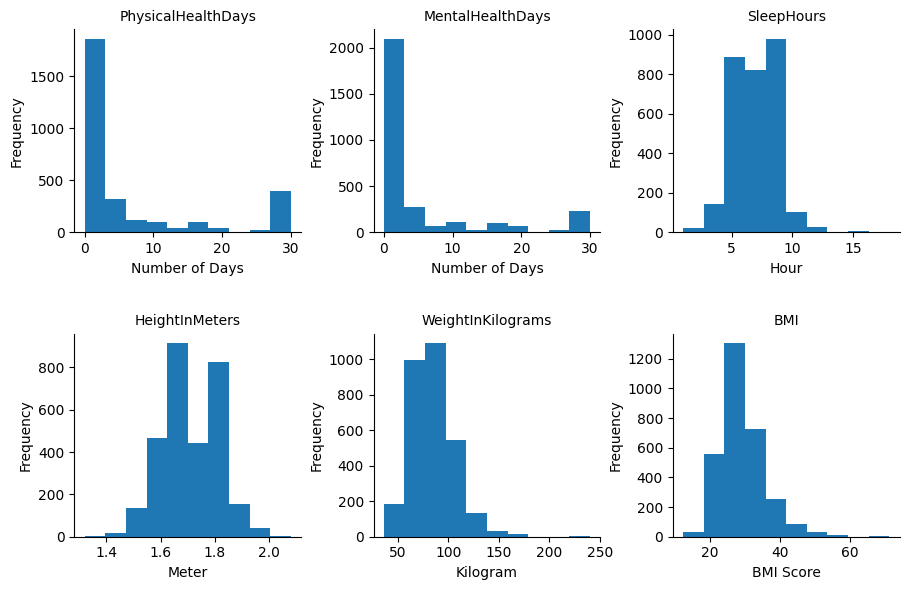

In [11]:
# Selecting only the numerical columns
numerical_columns = heart_sample.select_dtypes(include=['int64', 'float64'])
# Melt the DataFrame to create a long-form version suitable for FacetGrid
melted = pd.melt(numerical_columns)

# Create FacetGrid with histograms for each numerical column
g = sns.FacetGrid(melted, col="variable", col_wrap=3, sharex=False, sharey=False)
g.map(plt.hist, "value")
# Adjust plot labels and appearance
g.set_titles("{col_name}")
# Custom x-axis labels
x_labels = ["Number of Days", "Number of Days", "Hour", "Meter", "Kilogram", "BMI Score"]
# Set x and y labels for each subplot
for ax, xlabel in zip(g.axes.flat, x_labels):
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
plt.subplots_adjust(hspace=0.5)

plt.show()

# Data Preprocessing and Feature Engineering

The dataset is divided into train (70% of the original dataset), validation (15%) and test (15%) sets, so that the model can be trained on a large set of data, be tested on the validation set for model comparison, and finally be tested on a smaller set. Moreover, the target column was removed from both train and test sets and stored seperately to avoid having data leakage.


The purpose of feature engineering is to convert data into a form that the models can learn from them effectively. Since most machine learning models cannot work directly with strings, One Hot Encoder was adopted to convert categories into numerical indicator columns. Likewise, Standard Scaler was adopted to scale the numerical features (with a mean of ≈ 0, and standard deviation of ≈ 1) so that the models, specially SVC and Logistic Regression that are sensitive to feature scale, can have a more stable training and more balanced coefficients.

In [12]:
# Split the dataset into train and test sets
heart_train, heart_temprorary = sklearn.model_selection.train_test_split(heart_sample, test_size=0.3)

# Print the shapes of the main, train, and test datasets
print("Dataset shape: ", heart_sample.shape)
print("Train set shape: ", heart_train.shape)
print("Test set shape: ", heart_temprorary.shape)

Dataset shape:  (3000, 40)
Train set shape:  (2100, 40)
Test set shape:  (900, 40)


In [13]:
# Split the temprorary dataset into validation and test sets
heart_validation, heart_test = sklearn.model_selection.train_test_split(heart_temprorary, test_size=0.5)

# Print the shapes of the temprorary, validation, and test datasets
print("Dataset shape: ", heart_temprorary.shape)
print("Train set shape: ", heart_validation.shape)
print("Test set shape: ", heart_test.shape)

Dataset shape:  (900, 40)
Train set shape:  (450, 40)
Test set shape:  (450, 40)


In [14]:
# Seperate the target column from the rest of the train, validation and test dataset
x_train = heart_train.drop("HadHeartAttack", axis=1)
y_train = heart_train['HadHeartAttack']

x_validation = heart_validation.drop("HadHeartAttack", axis=1)
y_validation = heart_validation['HadHeartAttack']

x_test = heart_test.drop("HadHeartAttack", axis=1)
y_test = heart_test['HadHeartAttack']

print(x_train.shape)
print(y_train.shape)
print(x_validation.shape)
print(y_validation.shape)
print(x_test.shape)
print(y_test.shape)

(2100, 39)
(2100,)
(450, 39)
(450,)
(450, 39)
(450,)


In [15]:
# Store numerical values in numerical_attr and categorical values in categorical_attr
numerical_attr = x_train.select_dtypes(include=['int64', 'float64']).columns
categorical_attr = x_train.select_dtypes(include=['object']).columns

# Adopt Standard Scaler for numerical data and One Hot Encoding for categorical data
ct = sklearn.compose.ColumnTransformer(
    [
        ('standard_scaler', sklearn.preprocessing.StandardScaler(), numerical_attr),
        ('one_hot_encoder', sklearn.preprocessing.OneHotEncoder(), categorical_attr)
    ]
)

# Fit the x_train dataset with the Standard Scaler and One Hot Encoding
ct.fit(x_train)

# Transform both x_train and x_test dataset with the Standard Scaler and One Hot Encoding
x_train = ct.transform(x_train)
x_validation = ct.transform(x_validation)
x_test = ct.transform(x_test)

print(x_train.shape)
print(x_validation.shape)
print(x_test.shape)

(2100, 154)
(450, 154)
(450, 154)


# Model Training

Considering the dataset include both numerical and categorical data with a binary target column, Logistic Regression, Random Forest Classifier, SVC, and Decision Tree Classifier are tested in this pipeline. All models are trained on the train set, however, for model comparison, validation set score is determiner.

**Logistic Regression** is an ideal option since it was designed for binary classification, is highly interpretable, and the probabilistic output aids decision making for professionals.

**Random Forest Classifier** is another model designed for classification purposes which can handle large datasets well. Its performance is considered highly accurate and robust. However it is less interpretable than Logistic Regression and is computationally intensive.

**Support Vectore Classification** is one of the options to be tested for this pipeline because it was designed to handle linear classification task as well as non-linear (through kernels). SVC is also commonly used in medical diagnosis. This model is capable of producing highly accurate output for complex datasets, however, it is computationally expensive, difficult to interpret and needs careful tuning.

**Decision Tree** is the last model to test. It is a tree-like algorithm that categorize data into distinct groups based on their feature values. It is a strong option since not only it predicts the target, but it also shows which health factors are associated with that risk (high interpretability)

For each model, Grid Search Cross-Validation function is used to search for the best combination of hyperparameters across the provided grid. To measure the performance of models, Recall Score is prioritized as the best score since failing to detect a positive heart disease case can have severe consequences.

In [16]:
# Create scoring function
recall_scorer = make_scorer(recall_score, pos_label='Yes')

# Create a Logistic Regression model
lr = LogisticRegression(max_iter=10000, random_state=0)
# Define hyperparameters values to test during GridSearchCV
# 'C' tests different values for regularization strength
# 'solver' tests different optimization solvers
lr_parameters = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']}

# Create a GridSearchCV that trains Logistic Regression models
# Use all parameters combinations, measure by Recall Score, utilise 4-fold cross-validation
lr_clf = GridSearchCV(lr, lr_parameters, scoring=recall_scorer, cv=4)
# Fit multiple LR model on train dataset and find the best parameter combination
lr_clf.fit(x_train, y_train)

print("Best parameters combination:", lr_clf.best_params_)
print("Best recall score:", lr_clf.best_score_)

# Predict on validation set
y_validation_pred = lr_clf.predict(x_validation)
val_recall = recall_score(y_validation, y_validation_pred, pos_label='Yes')

print("Recall score on validation set:", val_recall)

Best parameters combination: {'C': 0.1, 'solver': 'liblinear'}
Best recall score: 0.7602611940298507
Recall score on validation set: 0.7914691943127962


In [17]:
rfc = RandomForestClassifier()
# 'n_estimators' tests different values for the number of decision trees in the forest to try
# 'max_depth' tests different values for maximum depth of each tree
rf_parameters = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [5, 10, 20, 30]}

rfc_clf = GridSearchCV(rfc, rf_parameters, scoring=recall_scorer, cv=4)
rfc_clf.fit(x_train, y_train)

print("Best parameters combination:", rfc_clf.best_params_)
print("Best score:", rfc_clf.best_score_)

y_validation_pred = rfc_clf.predict(x_validation)
val_recall = recall_score(y_validation, y_validation_pred, pos_label='Yes')

print("Recall score on validation set:", val_recall)

Best parameters combination: {'max_depth': 30, 'n_estimators': 100}
Best score: 0.7798507462686567
Recall score on validation set: 0.7962085308056872


In [18]:
svc = SVC()
# 'C' tests different values for regularization strength
# 'kernel' tests different values for kernel to determine how SVC seperates the data
svc_parameters = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']}

svc_clf = GridSearchCV(svc, svc_parameters, scoring=recall_scorer, cv=4)
svc_clf.fit(x_train, y_train)

print("Best parameters combination:", svc_clf.best_params_)
print("Best score:", svc_clf.best_score_)

y_validation_pred = svc_clf.predict(x_validation)
val_recall = recall_score(y_validation, y_validation_pred, pos_label='Yes')

print("Recall score on validation set:", val_recall)

Best parameters combination: {'C': 0.1, 'kernel': 'rbf'}
Best score: 0.7621268656716418
Recall score on validation set: 0.7725118483412322


In [19]:
dt_clf = DecisionTreeClassifier(random_state=1)
# 'max_depth' defines the maximum depth of the tree
# 'min_samples_leaf' defines the minimum number of samples required to split an internal node
# 'min_samples_split' defines the minimum number of samples required to be at a leaf node
# 'criterion' is a function to measure the quality of a split
dt_parameters = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
    }

dt_clf = GridSearchCV(dt_clf, dt_parameters, scoring=recall_scorer, cv=4)
dt_clf.fit(x_train, y_train)

print("Best parameters combination:", dt_clf.best_params_)
print("Best score:", dt_clf.best_score_)

y_validation_pred = dt_clf.predict(x_validation)
val_recall = recall_score(y_validation, y_validation_pred, pos_label='Yes')

print("Recall score on validation set:", val_recall)

Best parameters combination: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 19, 'min_samples_split': 2}
Best score: 0.7565298507462686
Recall score on validation set: 0.7345971563981043


# Model Assessment

The outcome of the evaluation metrics indicate Random Forest Classifier performs well in predicting heart attack cases.

The Accuracy metric shows 77% of all the predicted answers by model were correct, which suggest a strong general performance on the test set.

The Precision metric indicates that when the RFC model predicts a patient has had a heart attack, it is correct 75% of the time. The importance of a high Precision score is that fewer people are incorrectly identified as having had a heart attack.

The Recall metric output suggest that the RFC model successfully identified 77% of the actual heart attack cases. This means, although the model can capture most positive cases, there are still around 23% of true cases that the model fails to detect. In healthcare environment, that outcome fails to be accepted.

The F1 metrics refletcs a good balance between precision and recall with a score of 0.765.

Overall, the evaluation results shows that the pipeline offers a balanced predictive model with promising potentials for heart attack classification. However, since healthcare settings are sensitive environments that can have severe consequences even for the smallest errors, the model must be further improved to be used as a decision-support tool.

In [20]:
# RFC model predict the target in the test dataset
y_pred = rfc_clf.predict(x_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7711111111111111
Precision: 0.7567567567567568
Recall: 0.7741935483870968
F1 Score: 0.765375854214123


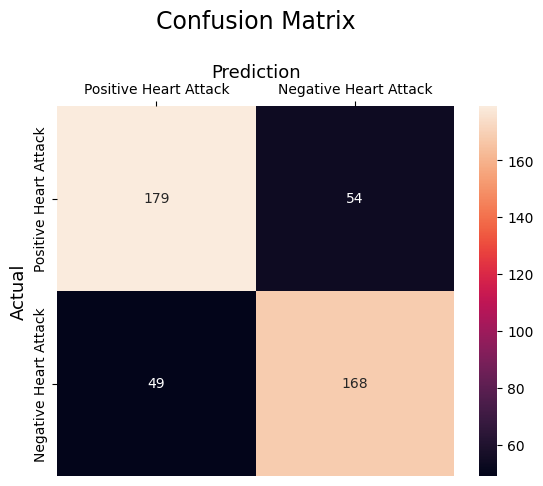

In [22]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='g',
            xticklabels=['Positive Heart Attack','Negative Heart Attack'],
            yticklabels=['Positive Heart Attack','Negative Heart Attack'])

plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=25)
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.show()

# Final Discussion


**Strengths**

The proposed pipeline uses a structured machine learning workflow that handles a mix of numerical and categorical data. The pipeline uses proper preprocessing techniques and applies hyperparameter tuning. At the end, the pipeline evaluates the top model on unseen test dataset and uses several evaluation metrics to assess the model's performance rigiously.


**Limitations**

The models were trained on only 3000 samples randomly selected from a larger dataset. The new small sample dataset may not fully represent the original population, rare patterns may be lost, and the models might have a different performance if they were trained on the original dataset. Moreover, The survey data from which the original dataset was made from may contain self-reporting biases.


**Business Implications**

Once the model achieves acceptable recall score that meets the healthcare settings standards, it can be helpful in identifying high-risk groups, reduce delayed diagnosis, and support preventive actions. However, even with an improved performance, this pipeline should not replace medical diagnosis by professionals, rather it should be used as a decision-support tool.


**Data-Driven Recommendations**

The pipeline should be used as an early screening aid and not a final diagnostic tool. Train the models on the original dataset rather than a small 3000 sample set. Replace row dropping with proper imputation techniques for missing values. Treat class imbalance in other features other than the target. Compare additional models such as XGBoost or Gradient Boosting.


**Explainability**

Logistic Regression is fairly explainable because coefficients can be interpreted, however, SVC and RFC are less explainable, especially with nonlinear kernels in SVC. Since in healthcare explainability is valuable, Logistic Regression may be more preferable even if the performance is slightly lower than the other models.


**Deployment Decision**

The model can be deployed as a decision-support or screening assistance tool, however, it is important for the machine learning models to be retrained on the original dataset, and reviewed by domain experts. With respect to the current performance, it is adviced to remain a prototype for analysis, rather than immediate deployment.

# References

[1] https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/data$0